In [11]:
import pandas as pd
import pymc as pm
import arviz as az
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Load dataset
df = pd.read_csv('Forest_Evolutionism_2025_result.csv')

df["player_cat"] = pd.Categorical(df["Player_ID"])
df["game_cat"] = pd.Categorical(df["Game_Type"])

player_idxs = df["player_cat"].cat.codes.values
game_idxs = df["game_cat"].cat.codes.values
player_names = df["player_cat"].cat.categories
game_names = df["game_cat"].cat.categories

y_obs = df["Rank"].values - 1

In [7]:
with pm.Model() as ranking_model:

    mu_p = pm.Normal("mu_p", mu=0, sigma=1)
    sigma_p = pm.HalfNormal("sigma_p", sigma=1)

    skill_raw = pm.Normal('skill_raw', mu=0, sigma=1, shape=len(player_names))
    skill = pm.Deterministic('skill', mu_p + skill_raw * sigma_p)
    game_effect = pm.Normal("game_effect", mu=0, sigma=1, shape=len(game_names))

    mu_y = -(skill[player_idxs] + game_effect[game_idxs])

    eps = pm.HalfNormal("eps", sigma=1)

    obs = pm.Normal("obs", mu=mu_y, sigma=eps, observed=y_obs)

    trace = pm.sample(10000, tune=2000, target_accept=0.99, random_seed=42)


Output()

In [9]:
# Save Summary Stats
summary_stats = az.summary(trace, var_names=["skill"])
summary_stats.index = player_names
summary_stats.to_csv("model_summary.csv")
print(summary_stats)

      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
CEQ -2.488  0.748  -3.814   -1.014      0.007    0.005   10065.0   13718.0   
HS  -3.258  0.716  -4.670   -1.961      0.007    0.005   10573.0   14279.0   
HYB -3.461  0.876  -5.168   -1.923      0.009    0.006    9253.0   13388.0   
HYC -2.585  0.714  -3.912   -1.221      0.007    0.005   10763.0   14952.0   
KB  -2.616  0.708  -3.857   -1.182      0.007    0.005   11166.0   14968.0   
LJY -2.388  0.739  -3.726   -0.965      0.008    0.004    9537.0   13993.0   
LKW -2.959  0.676  -4.276   -1.706      0.006    0.005   12119.0   15053.0   
LXS -3.237  0.713  -4.641   -1.949      0.007    0.005   10547.0   14004.0   
LYC -3.055  0.686  -4.399   -1.801      0.006    0.005   11940.0   14615.0   
LYT -2.721  0.789  -4.184   -1.181      0.007    0.006   12821.0   14786.0   
LYW -2.935  0.767  -4.464   -1.535      0.006    0.006   14512.0   14077.0   
MQR -3.008  0.747  -4.435   -1.569      0.007    0.006   13082.0

/usr/local/lib/python3.12/dist-packages/arviz/plots/traceplot.py:223: UserWarning: rcParams['plot.max_subplots'] (20) is smaller than the number of variables to plot (22), generating only 20 plots
  warnings.warn(


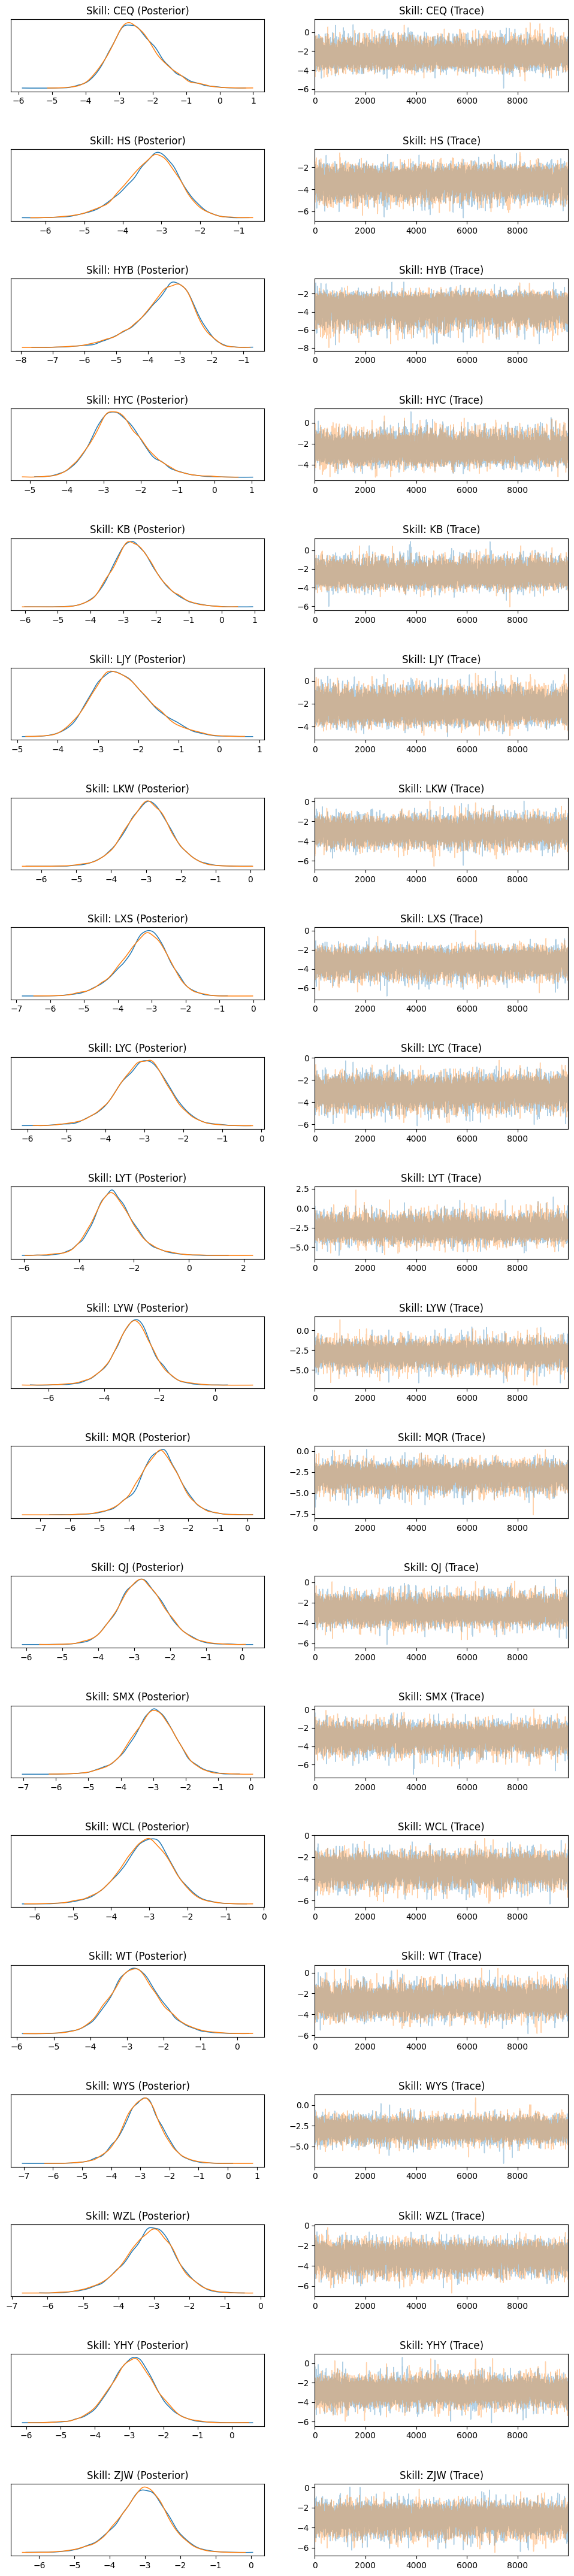

In [24]:
# Trace Plot
axes = az.plot_trace(trace, var_names=["skill"], coords={"skill_dim_0": list(range(len(player_names)))}, compact=False)
num_plots = axes.shape[0]
for i in range(num_plots):
    name = player_names[i]
    axes[i, 0].set_title(f"Skill: {name} (Posterior)")
    axes[i, 1].set_title(f"Skill: {name} (Trace)")
fig = axes[0][0].get_figure()
fig.set_size_inches(12, len(player_names) * 2.5)
plt.subplots_adjust(hspace=0.8)
plt.savefig("trace_plot.png", dpi=300)
plt.show()
plt.close()

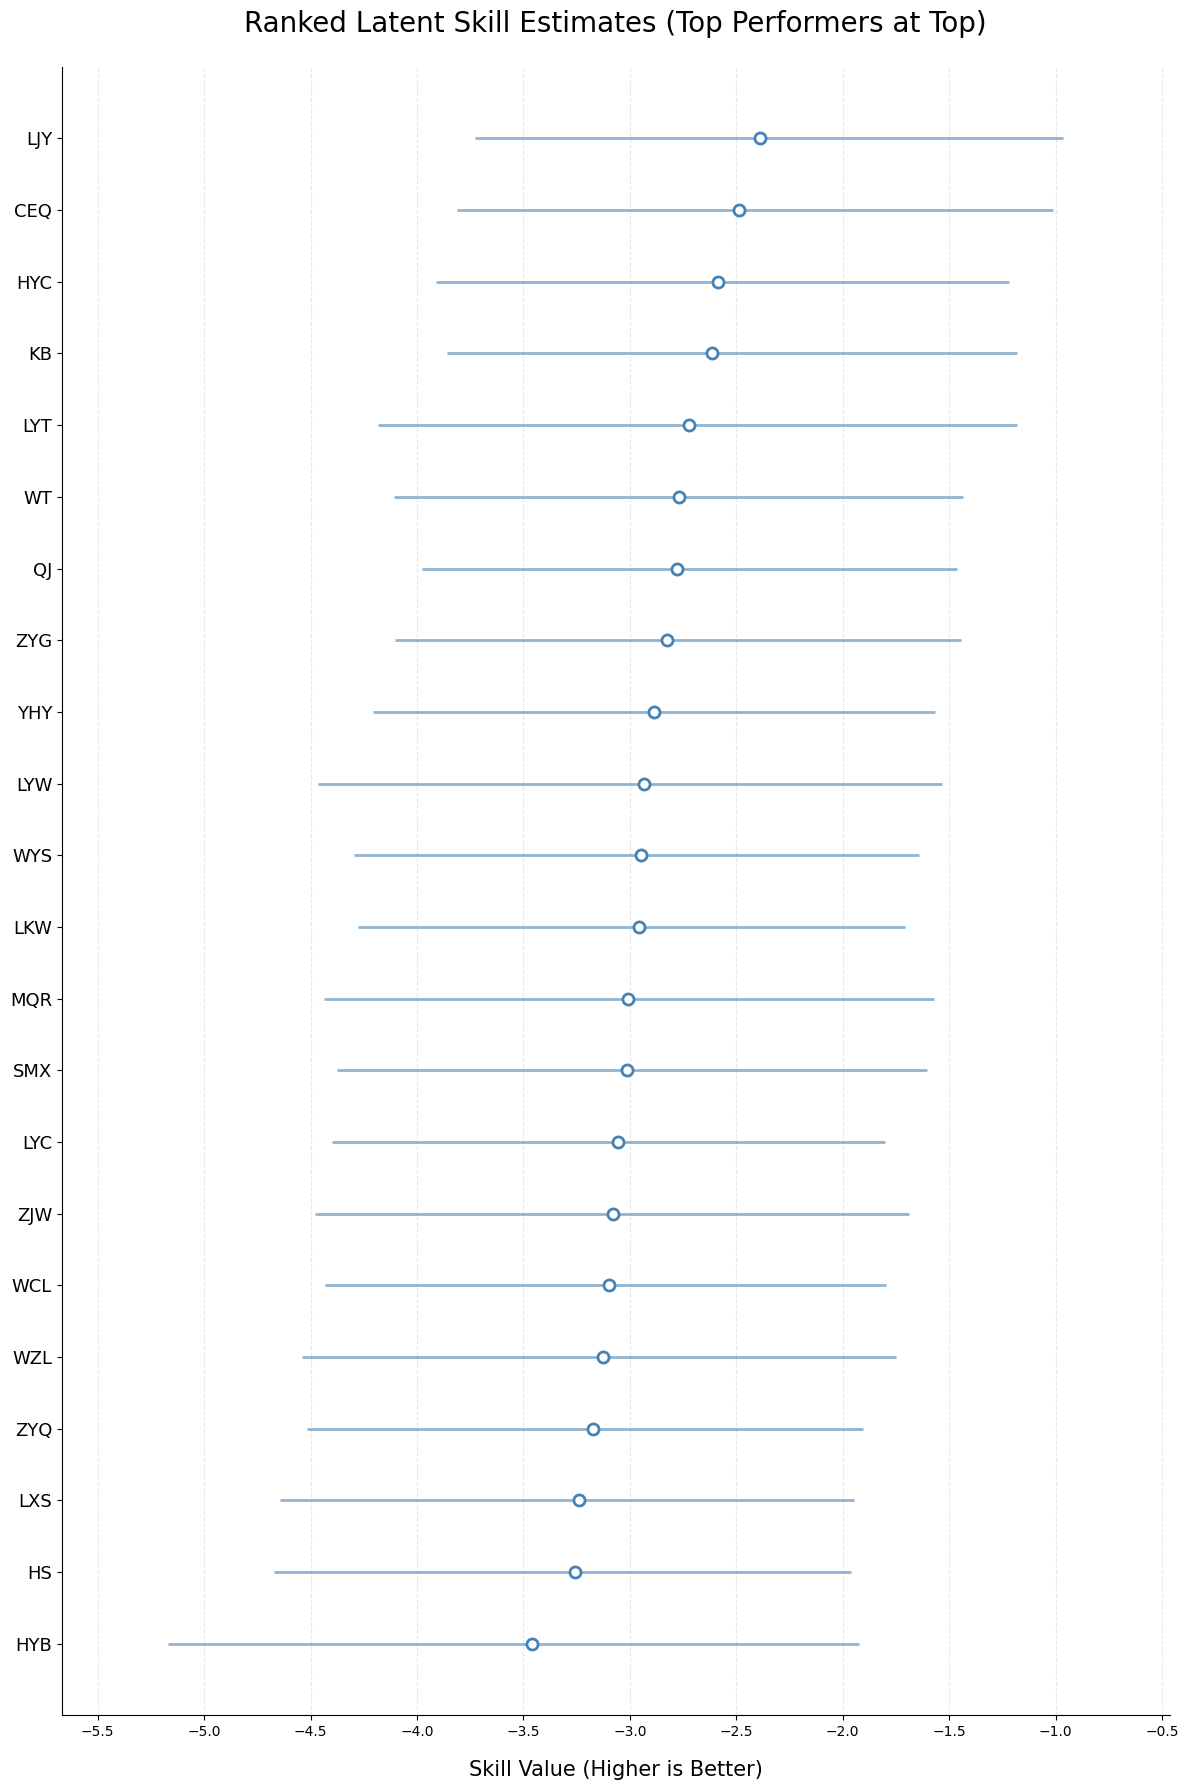

In [22]:
df_sorted = summary_stats.sort_values(by='mean', ascending=True)

fig, ax = plt.subplots(figsize=(12, 18))
y_pos = np.arange(len(df_sorted))
ax.hlines(y_pos, df_sorted['hdi_3%'], df_sorted['hdi_97%'],
          color='steelblue', alpha=0.6, linewidth=2, label='94% HDI')
ax.plot(df_sorted['mean'], y_pos, 'o', color='white',
        markeredgecolor='steelblue', markersize=8, markeredgewidth=2)

x_ticks = np.arange(-5.5, 0.5, 0.5)
ax.set_xticks(x_ticks)

ax.set_yticks(y_pos)
ax.set_yticklabels(df_sorted.index, fontsize=13)

ax.set_ylim(-1, len(df_sorted))
ax.set_xlim(df_sorted['hdi_3%'].min() - 0.5, df_sorted['hdi_97%'].max() + 0.5)

ax.set_title("Ranked Latent Skill Estimates (Top Performers at Top)", fontsize=20, pad=25)
ax.set_xlabel("Skill Value (Higher is Better)", fontsize=15, labelpad=15)

ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("skill_plot.png", dpi=300)
plt.show()
plt.close()

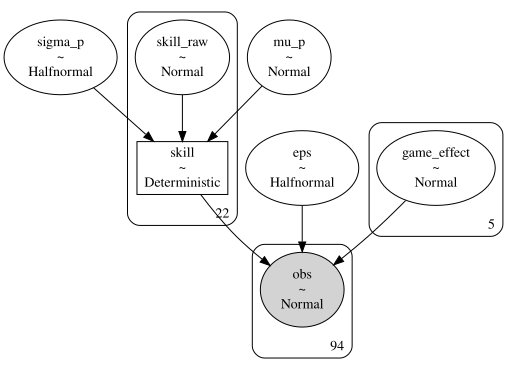

In [25]:
pm.model_to_graphviz(ranking_model)

In [13]:
# Generate Posterior Predictive Samples
with ranking_model:
    ppc = pm.sample_posterior_predictive(trace)

# Calculate Winning Probability
post_skills = trace.posterior["skill"].values.reshape(-1, len(player_names))
wins = np.argmax(post_skills, axis=1)
win_counts = np.bincount(wins, minlength=len(player_names))
win_probs = win_counts / len(wins)

prob_df = pd.DataFrame(
    {"Player": player_names, "Win_Probability": win_probs}
).sort_values(by="Win_Probability", ascending=False)

# Save the results
prob_df.to_csv("win_probability.csv", index=False)
print(prob_df)

# Plot Predictive Check

az.plot_ppc(ppc)
plt.savefig("ppc_plot.png")
plt.close()

Output()

   Player  Win_Probability
5     LJY          0.16720
0     CEQ          0.12760
3     HYC          0.09200
4      KB          0.08200
9     LYT          0.07700
15     WT          0.05295
12     QJ          0.04405
20    ZYG          0.04140
10    LYW          0.04100
18    YHY          0.03600
16    WYS          0.03170
11    MQR          0.02925
6     LKW          0.02630
13    SMX          0.02605
19    ZJW          0.02280
8     LYC          0.02070
17    WZL          0.01920
14    WCL          0.01635
21    ZYQ          0.01440
7     LXS          0.01220
1      HS          0.01115
2     HYB          0.00870


/tmp/ipykernel_7828/2379514376.py:22: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig("ppc_plot.png")
